In [115]:
import pickle
import pandas as pd
import glob, os
from troncamento_datasets import BaseDataset

df = pd.read_csv("troncamento_data.csv")
print("Total sentences: ", len(df))
original_len = len(df)
df = df[df["sent_it_prob"]>0.99].reset_index(drop=True)
print("Unlikely sentences: ", original_len - len(df), f"({round((original_len - len(df))/original_len*100, 2)}%)")
saved_embed_fs = glob.glob("saved_embeds/*.npy")
selected_ids = [int(os.path.basename(f).split("_")[0]) for f in saved_embed_fs]

df = df[df["id"].isin(selected_ids)].reset_index(drop=True)
print("Selected sentences: ", len(df), f"({round(len(df)/original_len*100, 2)}%)")
basedataset = BaseDataset(df, dataset_type="target", return_player=False)

Total sentences:  456234
Unlikely sentences:  213921 (46.89%)
Selected sentences:  75956 (16.65%)


In [116]:
gold_label_df = pd.read_csv("gold_labels.csv")
delete_idxs = []
for idx in range(len(gold_label_df)):
    uid = gold_label_df["unique_id"][idx]
    if uid not in basedataset.unique_id2idx:
        delete_idxs.append(idx)
gold_label_df.drop(labels=delete_idxs, inplace=True)
gold_label_df.reset_index(drop=True, inplace=True)

In [117]:
pred_fs = glob.glob("leave_one_out_predictions/*_preds.pickle")

In [118]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import tqdm

In [ ]:
# best_threshold = None
# best_f1 = -1
# for threshold in tqdm.tqdm(np.arange(0.0, 1.0, 0.001)):
#     pred_data = {
#         "true_e": [],
#         "pred_e": [],
#         "true_bad": [],
#         "pred_bad": [],
#         "p_e": [],
#         "p_bad": [],
#         "ap_e": [],
#         "ap_bad": [],
#     }
#     for f in pred_fs:
#         with open(f, "rb") as handle:
#             pred = pickle.load(handle)
#         uid = pred["unique_id"]
#         true = gold_label_df[gold_label_df["unique_id"]==uid]["label"].values[0]
#         if true==-1:
#             true_e = None
#             true_bad = 1
#         else:
#             true_e = true
#             true_bad = 0
#         p_e = pred["p_e"]
#         p_bad = pred["p_bad"]
#         if p_bad>=0.1:
#             pred_bad = 1
#             pred_e = None
#         else:
#             pred_bad = 0
#             if p_e>=0.5:
#                 pred_e = 1
#             else:
#                 pred_e = 0
#         pred_data["true_e"]+=[true_e]
#         pred_data["pred_e"]+=[pred_e]
#         pred_data["true_bad"]+=[true_bad]
#         pred_data["pred_bad"]+=[pred_bad]
#         pred_data["p_e"]+=[p_e]
#         pred_data["p_bad"]+=[p_bad]
#         pred_data["ap_e"]+=[pred["ap_e"]]
#         pred_data["ap_bad"]+=[pred["ap_bad"]]

#     pred_df = pd.DataFrame(pred_data)

#     y_true = pred_df["true_bad"]
#     y_pred = pred_df["pred_bad"]

#     acc = accuracy_score(y_true, y_pred)
#     f1 = f1_score(y_true, y_pred)
#     if f1>best_f1:
#         best_f1 = f1
#         best_threshold = threshold

# print("Best threshold: ", best_threshold)
# print("Best F1: ", best_f1)

In [126]:
pred_data = {
    "true_e": [],
    "pred_e": [],
    "true_bad": [],
    "pred_bad": [],
    "p_e": [],
    "p_bad": [],
    "ap_e": [],
    "ap_bad": [],
    "true": [],
}
for f in pred_fs:
    with open(f, "rb") as handle:
        pred = pickle.load(handle)
    uid = pred["unique_id"]
    true = gold_label_df[gold_label_df["unique_id"]==uid]["label"].values[0]
    if true==-1:
        true_e = None
        true_bad = 1
    else:
        true_e = true
        true_bad = 0
    p_e = pred["p_e"]
    p_bad = pred["p_bad"]
    if p_bad>=0.5:
        pred_bad = 1
        pred_e = None
    else:
        pred_bad = 0
        if p_e>=0.5:
            pred_e = 1
        else:
            pred_e = 0
    pred_data["true_e"]+=[true_e]
    pred_data["pred_e"]+=[pred_e]
    pred_data["true_bad"]+=[true_bad]
    pred_data["pred_bad"]+=[pred_bad]
    pred_data["p_e"]+=[p_e]
    pred_data["p_bad"]+=[p_bad]
    pred_data["ap_e"]+=[pred["ap_e"]]
    pred_data["ap_bad"]+=[pred["ap_bad"]]
    pred_data["true"]+=[true]

pred_df = pd.DataFrame(pred_data)

In [122]:
print("Total samples: ", len(pred_df))
y_true = pred_df["true_bad"]
y_pred = pred_df["pred_bad"]

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("Bad detection:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 score: {f1:.4f}")

y_true = pred_df.dropna()["true_e"]
y_pred = pred_df.dropna()["pred_e"]

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Vowel detection (valid only):")
print(f"Accuracy: {acc:.4f}")
print(f"F1 score: {f1:.4f}")

print("Mean average precision for bad head: ", np.mean(pred_df["ap_bad"]))
print("Mean average precision for vowel head (valid only): ", np.mean(pred_df["ap_e"]))

Total samples:  503
Bad detection:
Accuracy: 0.8489
F1 score: 0.3091
Vowel detection (valid only):
Accuracy: 0.7390
F1 score: 0.8401
Mean average precision for bad head:  0.4979676777246025
Mean average precision for vowel head (valid only):  0.8505936797920491


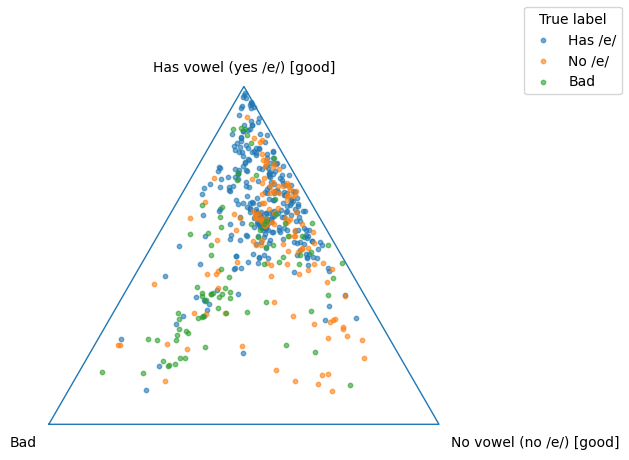

In [135]:
import matplotlib.pyplot as plt
all_p_e = pred_df["p_e"].tolist()
all_p_bad = pred_df["p_bad"].tolist()
p_e = np.array([float(x) for x in all_p_e])
p_bad = np.array([float(x) for x in all_p_bad])

p_BAD = p_bad
p_HAS = (1.0 - p_bad) * p_e
p_NO  = (1.0 - p_bad) * (1.0 - p_e)


S = p_BAD + p_HAS + p_NO
assert np.allclose(S, 1.0, atol=1e-6), (S.min(), S.max())

a = p_BAD
b = p_NO
c = p_HAS

x = b + 0.5 * c
y = (np.sqrt(3) / 2.0) * c

plot_df = pd.DataFrame({
    "x": x,
    "y": y,
    "true": pred_df["true"],
})


fig, ax = plt.subplots(figsize=(6, 5))

# triangle boundary
tri_x = [0, 1, 0.5, 0]
tri_y = [0, 0, np.sqrt(3)/2, 0]
ax.plot(tri_x, tri_y, lw=1)

# scatter
for label in [1, 0, -1]:
    subset = plot_df[plot_df["true"]==label]
    label = "Bad" if label==-1 else ("Has /e/" if label==1 else "No /e/")
    ax.scatter(data=subset, x="x", y="y", s=10, alpha=0.6, label=label)

# corner labels
ax.text(-0.03, -0.03, "Bad", ha="right", va="top")
ax.text(1.03, -0.03, "No vowel (no /e/) [good]", ha="left", va="top")
ax.text(0.5, np.sqrt(3)/2 + 0.03, "Has vowel (yes /e/) [good]", ha="center", va="bottom")

ax.set_aspect("equal", "box")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, np.sqrt(3)/2 + 0.08)
ax.axis("off")
fig.legend(title="True label", loc="upper right")

plt.tight_layout()
plt.savefig(f"ternary_bad_no_has.png", dpi=250, bbox_inches="tight")